In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
import json
import pickle
import random
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, 
                        message="invalid value encountered in double_scalars",
                        module="sklearn.metrics._classification")

print("All libraries have been successfully imported.")

All libraries have been successfully imported.


In [2]:
# Set the random seed
def set_seed(seed=3407):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"The random seed has been set to: {seed}")

set_seed(3407)

The random seed has been set to: 3407


In [3]:
# Configure the parameters
class FixedConfig:
    max_length = 101
    batch_size = 32
    data_path = 'HNRNPC'
    
    # Model parameters
    d_model = 128
    nhead = 8
    num_layers = 3
    dropout = 0.3
    structure_embed_dim = 16
    pairing_embed_dim = 16
    conv_out_channels = 64
    conv_kernel_size = 5
    
    # Training parameters
    num_epochs = 125
    learning_rate = 8e-5
    weight_decay = 1e-4
    patience = 15
    gradient_clip = 1.0
    
    # Class balance
    focal_alpha = 0.75
    focal_gamma = 2.0
    
    # Classifier
    classifier_hidden_dims = [64, 32]
    
    # Output path
    model_save_path = f"{data_path}/Output_Sequence_Only/model.pth"
    vocab_save_path = f"{data_path}/Output_Sequence_Only/vocab.pkl"
    metrics_save_path = f"{data_path}/Output_Sequence_Only/metrics.csv"
    plots_save_dir = f"{data_path}/Output_Sequence_Only/plots"
    
    print(f"Parameter settings have been successfully completed.")

config = FixedConfig()

Parameter settings have been successfully completed.


In [4]:
# Methods definition
# Enhance the dataset
class EnhancedRNADataset(Dataset):
    def __init__(self, dataframe, kmer_vocab=None, max_length=101, augment=False):
        self.data = dataframe
        self.max_length = max_length
        self.augment = augment
        
        if kmer_vocab is None:
            self.kmer_vocab = self._build_vocab()
        else:
            self.kmer_vocab = kmer_vocab
            
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        if self.pad_token not in self.kmer_vocab:
            self.kmer_vocab[self.pad_token] = len(self.kmer_vocab)
        if self.unk_token not in self.kmer_vocab:
            self.kmer_vocab[self.unk_token] = len(self.kmer_vocab)
            
        self.vocab_size = len(self.kmer_vocab)
        
    def _build_vocab(self):
        all_kmers = []
        for seq in self.data['sequence']:
            kmers = seq.split()
            all_kmers.extend(kmers)
        kmer_counts = Counter(all_kmers)
        return {kmer: idx for idx, (kmer, _) in enumerate(kmer_counts.most_common())}
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Sequence processing
        sequence = row['sequence']
        kmers = sequence.split()
        seq_indices = [self.kmer_vocab.get(kmer, self.kmer_vocab[self.unk_token]) 
                      for kmer in kmers[:self.max_length]]
        
        if len(seq_indices) < self.max_length:
            seq_indices = seq_indices + [self.kmer_vocab[self.pad_token]] * (self.max_length - len(seq_indices))
        else:
            seq_indices = seq_indices[:self.max_length]
            
        # Secondary structure characteristics processing
        structure = eval(row['structure']) if isinstance(row['structure'], str) else row['structure']
        if len(structure) < self.max_length:
            structure = structure + [0] * (self.max_length - len(structure))
        else:
            structure = structure[:self.max_length]
            
        # Base pairing probability processing
        pairing_prob = eval(row['pairing_probabilities']) if isinstance(row['pairing_probabilities'], str) else row['pairing_probabilities']
        if len(pairing_prob) < self.max_length:
            pairing_prob = pairing_prob + [0.0] * (self.max_length - len(pairing_prob))
        else:
            pairing_prob = pairing_prob[:self.max_length]
            
        label = row['label']
        
        # Convert to tensor
        sequence_tensor = torch.tensor(seq_indices, dtype=torch.long)
        structure_tensor = torch.tensor(structure, dtype=torch.long)
        pairing_prob_tensor = torch.tensor(pairing_prob, dtype=torch.float)
        label_tensor = torch.tensor(label, dtype=torch.float)
        
        return {
            'sequence': sequence_tensor,
            'structure': structure_tensor,
            'pairing_prob': pairing_prob_tensor,
            'label': label_tensor
        }

# Position encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]

# Model
class RNAModel(nn.Module):
    def __init__(self, vocab_size):
        super(RNAModel, self).__init__()
        
        # Embedding layer
        self.sequence_embedding = nn.Embedding(vocab_size, config.d_model)
        
        # Convolutional layer
        conv_input_dim = config.d_model
        self.conv1 = nn.Conv1d(conv_input_dim, config.conv_out_channels, 
                              kernel_size=config.conv_kernel_size, padding=config.conv_kernel_size//2)
        self.conv2 = nn.Conv1d(config.conv_out_channels, config.conv_out_channels*2, 
                              kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(config.conv_out_channels)
        self.bn2 = nn.BatchNorm1d(config.conv_out_channels*2)
        self.conv_activation = nn.ReLU()
        self.conv_dropout = nn.Dropout(config.dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.conv_out_channels*2,
            nhead=config.nhead,
            dim_feedforward=config.conv_out_channels*4,
            dropout=config.dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, config.num_layers)
        self.pos_encoding = PositionalEncoding(config.conv_out_channels*2, config.max_length)
        
        # Classifier
        classifier_layers = []
        input_dim = config.conv_out_channels*2
        
        for hidden_dim in config.classifier_hidden_dims:
            classifier_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout)
            ])
            input_dim = hidden_dim
            
        classifier_layers.append(nn.Linear(input_dim, 1))
        self.classifier = nn.Sequential(*classifier_layers)
        
        # Initialize weights
        self._initialize_weights()
        
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.1)
            elif isinstance(module, nn.Conv1d):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
        
    def forward(self, sequence, structure, pairing_prob):
        batch_size = sequence.size(0)
        
        # Embedding
        seq_emb = self.sequence_embedding(sequence)
        
        # Merge features
        combined_emb = torch.cat([seq_emb], dim=-1)
        
        # Convolutional layer
        conv_input = combined_emb.transpose(1, 2)
        conv1_out = self.conv1(conv_input)
        conv1_out = self.bn1(conv1_out)
        conv1_out = self.conv_activation(conv1_out)
        conv1_out = self.conv_dropout(conv1_out)
        
        conv2_out = self.conv2(conv1_out)
        conv2_out = self.bn2(conv2_out)
        conv2_out = self.conv_activation(conv2_out)
        conv2_out = self.conv_dropout(conv2_out)
        
        # Transformer
        # The input shape should be (seq_len, batch_size, d_model)
        transformer_input = conv2_out.transpose(1, 2)  # (batch_size, seq_len, d_model)
        transformer_input = transformer_input.transpose(0, 1)  # (seq_len, batch_size, d_model)
        transformer_input = self.pos_encoding(transformer_input)  # (seq_len, batch_size, d_model)
        transformer_out = self.transformer_encoder(transformer_input)  # (seq_len, batch_size, d_model)
        transformer_out = transformer_out.transpose(0, 1)  # (batch_size, seq_len, d_model)
        
        # Global pooling
        pooled = transformer_out.mean(dim=1)  # (batch_size, d_model)
        
        # Classification
        logits = self.classifier(pooled)
        return logits.squeeze()
    
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        
        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss    

# Calculate all metrics
def calculate_all_metrics(y_true, y_pred, threshold=0.5):
    # Binary predictions
    y_pred_binary = (y_pred > threshold).astype(int)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    # Basic metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    # MCC
    mcc = matthews_corrcoef(y_true, y_pred_binary)
    
    # AUC metrics
    auroc = roc_auc_score(y_true, y_pred)
    auprc = average_precision_score(y_true, y_pred)
    
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1-Score': f1,
        'MCC': mcc,
        'AUROC': auroc,
        'AUPRC': auprc,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'Threshold': threshold
    }
    
    return metrics

# Plotting functions
def plot_training_curves(train_losses, val_losses, val_aurocs, val_auprcs, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss curve
    epochs = range(1, len(train_losses) + 1)
    axes[0, 0].plot(epochs, train_losses, 'b-', label='Train Loss')
    axes[0, 0].plot(epochs, val_losses, 'r-', label='Evaluate Loss')
    axes[0, 0].set_title('Train and Evaluate Loss')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # AUROC curve
    axes[0, 1].plot(epochs, val_aurocs, 'g-', label='Evaluate AUROC')
    axes[0, 1].set_title('Evaluate AUROC')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('AUROC')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # AUPRC curve
    axes[1, 0].plot(epochs, val_auprcs, 'purple', label='Evaluate AUPRC')
    axes[1, 0].set_title('Evaluate AUPRC')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('AUPRC')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Learning rate curve (if available)
    if hasattr(config, 'learning_rates'):
        axes[1, 1].plot(epochs, config.learning_rates[:len(epochs)], 'orange', label='Learning Rate')
        axes[1, 1].set_title('Learning Rate')
        axes[1, 1].set_xlabel('Epochs')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()  # Display the image
    plt.close()

def plot_roc_curve(y_true, y_pred, save_path):
    """Plot ROC curve"""
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auroc = roc_auc_score(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auroc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()  # Display the image
    plt.close()

def plot_pr_curve(y_true, y_pred, save_path):
    """Plot Precision-Recall curve"""
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    auprc = average_precision_score(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUPRC = {auprc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()  # Display the image
    plt.close()

def plot_confusion_matrix(y_true, y_pred, threshold=0.5, save_path=None):
    """Plot confusion matrix"""
    y_pred_binary = (y_pred > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_binary)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix (Threshold = {threshold:.2f})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        plt.show()  # Display the image
        plt.close()
    else:
        plt.show()

def plot_probability_distribution(y_true, y_pred, threshold, save_path):
    """Plot probability distribution for positive and negative samples"""
    positive_probs = y_pred[y_true == 1]
    negative_probs = y_pred[y_true == 0]
    
    plt.figure(figsize=(10, 6))
    plt.hist(positive_probs, bins=50, alpha=0.7, label='Positive Samples', color='green')
    plt.hist(negative_probs, bins=50, alpha=0.7, label='Negative Samples', color='red')
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Threshold = {threshold:.2f}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title('Predicted Probability Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()  # Display the image
    plt.close()

# Training function
def train(model, train_loader, val_loader, device):
    # Use Focal Loss
    criterion = FocalLoss(alpha=config.focal_alpha, gamma=config.focal_gamma)
    
    # Optimizer
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
        betas=(0.9, 0.999)
    )
    
    # Learning rate scheduling - Using cosine annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.num_epochs, eta_min=1e-7
    )
    
    train_losses = []
    val_losses = []
    val_aurocs = []
    val_auprcs = []
    learning_rates = []
    best_val_auc = 0.0
    patience_counter = 0
    
    print("Training start...")
    
    for epoch in range(config.num_epochs):
        # Train phase
        model.train()
        train_loss = 0.0
        batch_count = 0
        
        all_preds = []
        all_labels = []
        
        for batch in train_loader:
            sequence = batch['sequence'].to(device)
            structure = batch['structure'].to(device)
            pairing_prob = batch['pairing_prob'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            logits = model(sequence, structure, pairing_prob)
            loss = criterion(logits, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            optimizer.step()
            
            train_loss += loss.item()
            batch_count += 1
            
            # Collect predictions
            with torch.no_grad():
                preds = torch.sigmoid(logits)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        train_loss /= batch_count
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # Evaluate phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        
        with torch.no_grad():
            for batch in val_loader:
                sequence = batch['sequence'].to(device)
                structure = batch['structure'].to(device)
                pairing_prob = batch['pairing_prob'].to(device)
                labels = batch['label'].to(device)
                
                logits = model(sequence, structure, pairing_prob)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                preds = torch.sigmoid(logits)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_preds = np.array(val_preds)
        val_true = np.array(val_true)
        
        # Calculate indicators
        try:
            val_auc = roc_auc_score(val_true, val_preds)
            val_auprc = average_precision_score(val_true, val_preds)
        except:
            val_auc = 0.5
            val_auprc = 0.5
            
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_aurocs.append(val_auc)
        val_auprcs.append(val_auprc)
        learning_rates.append(optimizer.param_groups[0]['lr'])
        
        # Analyze the prediction distribution
        train_pred_ratio = np.mean(all_preds > 0.5)
        val_pred_ratio = np.mean(val_preds > 0.5)
        train_true_ratio = np.mean(all_labels)
        val_true_ratio = np.mean(val_true)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f'Epoch [{epoch+1}/{config.num_epochs}]')
        print(f'  Train loss: {train_loss:.4f}, Evaluate loss: {val_loss:.4f}')
        print(f'  Evaluate AUROC: {val_auc:.4f}, Evaluate AUPRC: {val_auprc:.4f}')
        print(f'  Learning rate: {current_lr:.2e}')
        print(f'  Train set - Real:    {train_true_ratio:.3f}, Predict: {train_pred_ratio:.3f}')
        print(f'  Evaluate set - Real: {val_true_ratio:.3f}, Predict: {val_pred_ratio:.3f}')
        
        # Early stop
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            torch.save(model.state_dict(), config.model_save_path)
            print(f'  Save the best model, AUROC: {val_auc:.4f}')
        else:
            patience_counter += 1
            
        # Update learning rate
        scheduler.step()
        
        if patience_counter >= config.patience:
            print(f'\nEarly stopping occurred at the {epoch + 1}th epoch.')
            break
            
        print('-' * 50)
    
    # Store learning rates for plotting
    config.learning_rates = learning_rates
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_aurocs': val_aurocs,
        'val_auprcs': val_auprcs,
        'best_val_auc': best_val_auc
    }

# Test function
def comprehensive_test(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            sequence = batch['sequence'].to(device)
            structure = batch['structure'].to(device)
            pairing_prob = batch['pairing_prob'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(sequence, structure, pairing_prob)
            preds = torch.sigmoid(logits)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Search for multiple thresholds
    thresholds = np.arange(0.1, 0.9, 0.05)
    results = []
    
    for threshold in thresholds:
        metrics = calculate_all_metrics(all_labels, all_preds, threshold)
        results.append(metrics)
    
    # Select the optimal threshold based on F1 score
    best_result = max(results, key=lambda x: x['Accuracy'])
    
    print(f"\nPerformance of the test set (threshold={best_result['Threshold']:.2f}):")
    print(f"AUROC:       {best_result['AUROC']:.4f}")
    print(f"AUPRC:       {best_result['AUPRC']:.4f}")
    print(f"Accuracy:    {best_result['Accuracy']:.4f}")
    print(f"Precision:   {best_result['Precision']:.4f}")
    print(f"Sensitivity: {best_result['Sensitivity']:.4f}")
    print(f"F1-Score:    {best_result['F1-Score']:.4f}")
    print(f"Specificity: {best_result['Specificity']:.4f}")
    print(f"MCC:         {best_result['MCC']:.4f}")
    
    
    # Analyze prediction distribution 
    pred_ratio = np.mean(all_preds > 0.5)
    true_ratio = np.mean(all_labels)

    return {
        'all_metrics': best_result,
        'all_results': results,
        'predictions': all_preds,
        'labels': all_labels,
        'best_threshold': best_result['Threshold']
    }

# Save metrics to CSV
def save_metrics_to_csv(metrics, save_path):
    """Save metrics to CSV file"""
    df = pd.DataFrame([metrics])
    df.to_csv(save_path, index=False)
    print(f"Metrics saved to {save_path}")

print(f"Methods definition completed")

Methods definition completed


In [5]:
# Preparations before train
# Data loading
print("Data loading...")
train_df = pd.read_csv(f'{config.data_path}/train.tsv', sep='\t')
eval_df = pd.read_csv(f'{config.data_path}/eval.tsv', sep='\t')
test_df = pd.read_csv(f'{config.data_path}/test.tsv', sep='\t')

print(f"Train set:    {len(train_df)}, Positive sample ratio: {train_df['label'].mean():.3f}")
print(f"Evaluate set: {len(eval_df)}, Positive sample ratio: {eval_df['label'].mean():.3f}")
print(f"Test set:     {len(test_df)}, Positive sample ratio: {test_df['label'].mean():.3f}")

# Create datasets
train_dataset = EnhancedRNADataset(train_df, max_length=config.max_length)
eval_dataset = EnhancedRNADataset(eval_df, kmer_vocab=train_dataset.kmer_vocab, max_length=config.max_length)
test_dataset = EnhancedRNADataset(test_df, kmer_vocab=train_dataset.kmer_vocab, max_length=config.max_length)

# Save the vocabulary list
os.makedirs(config.plots_save_dir, exist_ok=True)
with open(config.vocab_save_path, 'wb') as f:
    pickle.dump(train_dataset.kmer_vocab, f)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {device}")

Data loading...
Train set:    2400, Positive sample ratio: 0.492
Evaluate set: 300, Positive sample ratio: 0.543
Test set:     300, Positive sample ratio: 0.523
Device used: cuda


In [6]:
# Train the model
print("Start training the model...")
model = RNAModel(vocab_size=train_dataset.vocab_size).to(device)

results = train(model, train_loader, eval_loader, device)
print(f"\nBest evaluate AUROC: {results['best_val_auc']:.4f}")

Start training the model...
Training start...
Epoch [1/125]
  Train loss: 0.2061, Evaluate loss: 0.1652
  Evaluate AUROC: 0.7060, Evaluate AUPRC: 0.7463
  Learning rate: 8.00e-05
  Train set - Real:    0.492, Predict: 0.465
  Evaluate set - Real: 0.543, Predict: 0.743
  Save the best model, AUROC: 0.7060
--------------------------------------------------
Epoch [2/125]
  Train loss: 0.1842, Evaluate loss: 0.1978
  Evaluate AUROC: 0.7276, Evaluate AUPRC: 0.7673
  Learning rate: 8.00e-05
  Train set - Real:    0.492, Predict: 0.450
  Evaluate set - Real: 0.543, Predict: 0.497
  Save the best model, AUROC: 0.7276
--------------------------------------------------
Epoch [3/125]
  Train loss: 0.1662, Evaluate loss: 0.1575
  Evaluate AUROC: 0.7243, Evaluate AUPRC: 0.7712
  Learning rate: 7.99e-05
  Train set - Real:    0.492, Predict: 0.433
  Evaluate set - Real: 0.543, Predict: 0.490
--------------------------------------------------
Epoch [4/125]
  Train loss: 0.1457, Evaluate loss: 0.2369


In [7]:
# Load the best model for testing
model.load_state_dict(torch.load(config.model_save_path))
print("Load the best model for testing...")

# Carry out the test
print("\nTesting start...")
test_results = comprehensive_test(model, test_loader, device)

Load the best model for testing...

Testing start...

Performance of the test set (threshold=0.45):
AUROC:       0.8674
AUPRC:       0.8820
Accuracy:    0.7767
Precision:   0.7500
Sensitivity: 0.8599
F1-Score:    0.8012
Specificity: 0.6853
MCC:         0.5558


Metrics saved to HNRNPC/Output_Sequence_Only/metrics.csv
Generating plots...
Plotting training curves...


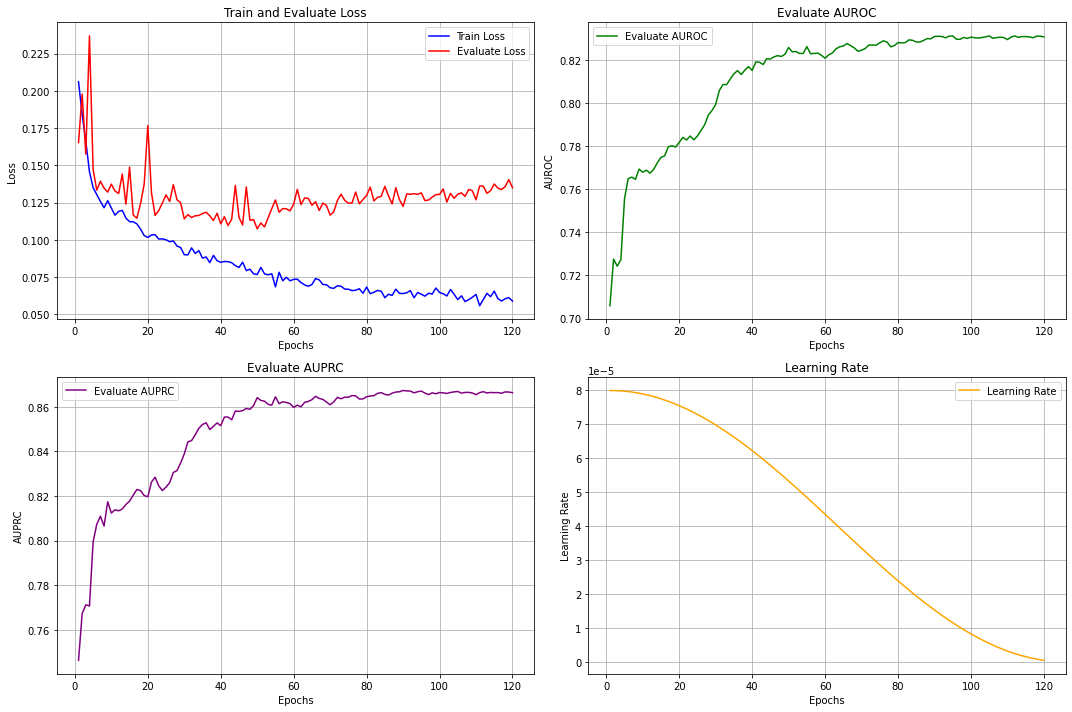

Plotting ROC curve...


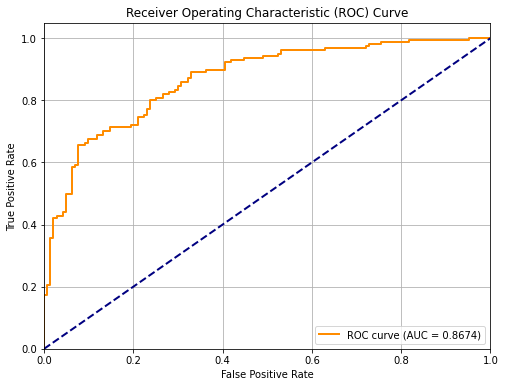

Plotting PR curve...


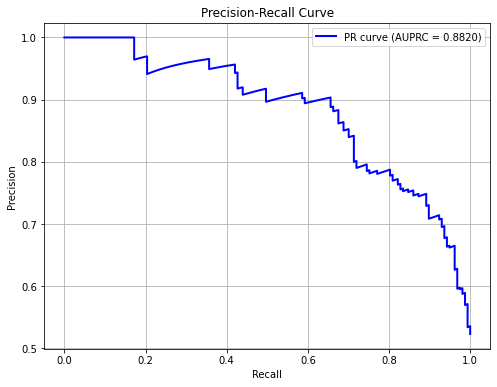

Plotting confusion matrix...


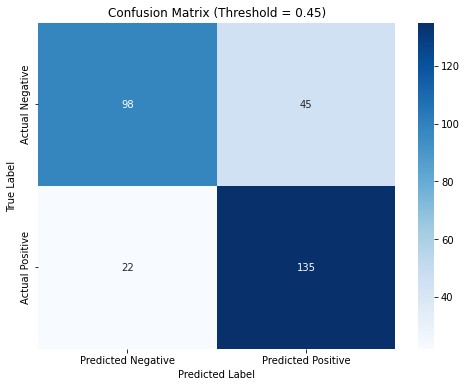

Plotting probability distribution...


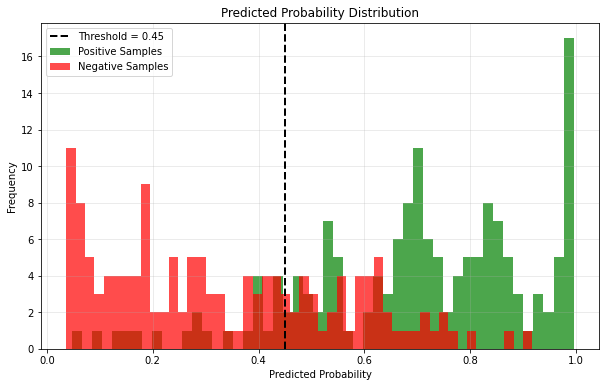

Detailed prediction results for the test set have been saved to HNRNPC/Output/test_predictions.tsv
All tasks completed successfully!


In [8]:
# Save metrics to CSV
save_metrics_to_csv(test_results['all_metrics'], config.metrics_save_path)

# Generate all plots
print("Generating plots...")

# Training curves
print("Plotting training curves...")
plot_training_curves(
    results['train_losses'], 
    results['val_losses'], 
    results['val_aurocs'],
    results['val_auprcs'],
    os.path.join(config.plots_save_dir, 'training_curves.png')
)

# ROC curve
print("Plotting ROC curve...")
plot_roc_curve(
    test_results['labels'],
    test_results['predictions'],
    os.path.join(config.plots_save_dir, 'roc_curve.png')
)

# PR curve
print("Plotting PR curve...")
plot_pr_curve(
    test_results['labels'],
    test_results['predictions'],
    os.path.join(config.plots_save_dir, 'pr_curve.png')
)

# Confusion matrix
print("Plotting confusion matrix...")
plot_confusion_matrix(
    test_results['labels'],
    test_results['predictions'],
    test_results['best_threshold'],
    os.path.join(config.plots_save_dir, 'confusion_matrix.png')
)

# Probability distribution
print("Plotting probability distribution...")
plot_probability_distribution(
    test_results['labels'],
    test_results['predictions'],
    test_results['best_threshold'],
    os.path.join(config.plots_save_dir, 'probability_distribution.png')
)

# Export detailed prediction results of the test
test_df_with_pred = test_df.copy()
test_df_with_pred['predicted_probability'] = test_results['predictions']
test_df_with_pred['predicted_label'] = (test_results['predictions'] > test_results['best_threshold']).astype(int)
output_pred_path = os.path.join(config.data_path, "Output", "test_predictions.tsv")
test_df_with_pred.to_csv(output_pred_path, sep='\t', index=False)
print(f"Detailed prediction results for the test set have been saved to {output_pred_path}")

print("All tasks completed successfully!")